## Load and Inspect Data

In [1]:
import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import shap

/home/jwalker/dev/java/auction-system/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the synthetic data we generated in Ticket 1
df = pd.read_csv("fraud_dataset.csv")

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (5500, 8)


,user_name,bid_amount,ip_address,user_agent,reaction_time_ms,bid_count_last_min,is_new_ip,is_fraud
0,mary50,3741.39,40.246.25.231,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_11_2...,3248,5,1,0
1,woodardpamela,2427.19,168.67.203.221,Mozilla/5.0 (X11; Linux x86_64; rv:1.9.6.20) G...,4027,2,0,0
2,shawnrogers,3411.73,216.231.122.107,Opera/8.54.(Windows NT 11.0; brx-IN) Presto/2....,3086,1,0,0
3,charles44,175.02,33.172.103.187,Mozilla/5.0 (compatible; MSIE 7.0; Windows 98;...,1931,3,1,0
4,patriciahuffman,4779.75,175.3.170.223,Mozilla/5.0 (Windows NT 6.2; az-AZ; rv:1.9.0.2...,1866,2,0,0


## Pre-Processing

In [3]:
X = df.drop(columns=['is_fraud', 'user_name']) 
y = df['is_fraud']

cat_features = ['ip_address', 'user_agent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Training

In [4]:
model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss',
    verbose=50 # Print progress every 50 iterations
)

model.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_test, y_test))

0:	learn: 0.4157277	test: 0.4161610	best: 0.4161610 (0)	total: 60.8ms	remaining: 12.1s
50:	learn: 0.0254109	test: 0.0287733	best: 0.0287733 (50)	total: 371ms	remaining: 1.08s
100:	learn: 0.0202311	test: 0.0279167	best: 0.0279167 (100)	total: 649ms	remaining: 636ms
150:	learn: 0.0151478	test: 0.0275860	best: 0.0270906 (126)	total: 962ms	remaining: 312ms
199:	learn: 0.0119259	test: 0.0288912	best: 0.0270906 (126)	total: 1.26s	remaining: 0us

bestTest = 0.02709060248
bestIteration = 126

Shrink model to first 127 iterations.


CatBoostClassifier(depth=6, iterations=200, learning_rate=0.1, loss_function='Logloss', verbose=50)

## Visualization

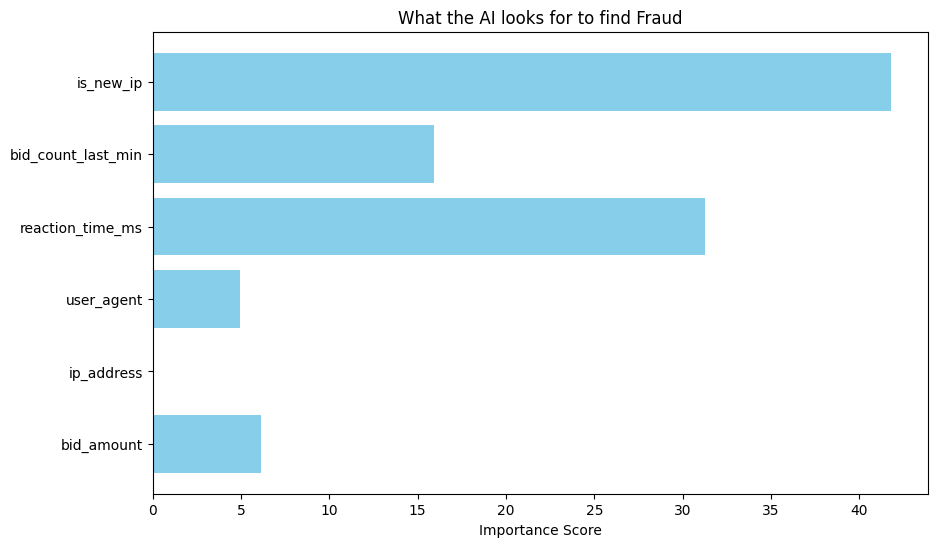

In [5]:
importances = model.get_feature_importance()
feature_names = X.columns

plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances, color='skyblue')
plt.xlabel("Importance Score")
plt.title("What the AI looks for to find Fraud")
plt.savefig("feature_importance.png") 
plt.show()

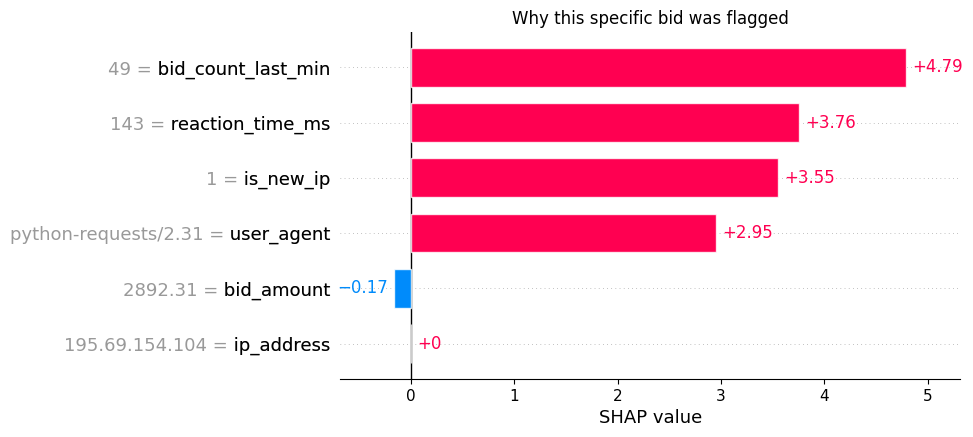

In [6]:
# Calculate SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Visualize the first prediction using Matplotlib
# This is a "Waterfall" plot - excellent for showing which features 
# pushed a specific bid toward a "Fraud" classification.
plt.figure()
shap.plots.bar(explainer(X_test)[0], show=False)
plt.title("Why this specific bid was flagged")
plt.savefig("shap_explanation.png", bbox_inches='tight')
plt.show()

## Export for the Java/FastAPI Bridge

In [7]:
model.save_model("fraud_model.cbm")
print("✅ Model exported as fraud_model.cbm")

✅ Model exported as fraud_model.cbm
